# Practical 1 report: preparing biological data for machine learning

**Student:** Yevhenii Zasko  
**Date:**  20.09
**Practical:** 1 - Data to ML-ready format

## Task

Data_Cortex_Nuclear.xls
The dataset is available from the UCI Machine Learning Repository at: https://archive.ics.uci.edu/dataset/342/mice%2Bprotein%2Bexpression

The dataset contains 1,080 rows, expression levels for 77 proteins or protein modifications, measurements from 72 mice, and 15 measurements per mouse. It also includes MouseID, Genotype, Treatment, Behavior, and an eight-level composite class.

What are the 15 measurements?
For each mouse sample, the original reverse-phase protein array (RPPA) experiment used three technical replicate spots at each point of a five-point dilution series:

1 mouse × 5 dilution points × 3 technical replicates = 15 rows
The dilution points are different concentrations of the same sample, and the replicate spots are repeated technical measurements. They are not 15 independent mice or 15 biological replicates. The public UCI spreadsheet does not contain separate dilution-level or replicate-number columns, so the exact dilution curve cannot be reconstructed alone, meaning you need to select one dilution level. In the distributed file, labels such as 309_1 through 309_15 are row-level measurement identifiers: the part before the final underscore identifies the biological mouse, while the suffix identifies the measurement record.

Create a derived grouping variable before splitting:

mice["mouse_id"] = mice["MouseID"].astype(str).str.rsplit("_", n=1).str[0]
Your goal is to turn the data into a defensible ML-ready dataset while keeping measurement, mouse, experimental-condition, and target roles separate.



In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA = Path(".")
RANDOM_STATE = 200926

In [ ]:
data = pd.read_excel("data/Data_Cortex_Nuclear.xls")

In [6]:
data

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,...,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823,Ts65Dn,Saline,S/C,t-SC-s
1076,J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,...,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478,Ts65Dn,Saline,S/C,t-SC-s
1077,J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,...,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825,Ts65Dn,Saline,S/C,t-SC-s
1078,J3295_14,0.221242,0.412894,0.243974,1.876347,2.384088,0.208897,0.173623,2.086028,0.192044,...,0.196296,0.397676,0.335936,0.251317,0.365353,1.404031,Ts65Dn,Saline,S/C,t-SC-s


## 2. Data-preparation readiness

Complete this section before describing modelling results.

## Scientific purpose and provenance

- [x] Is the biological question and prediction task stated clearly?
    "Your goal is to turn the data into a defensible ML-ready dataset while keeping measurement, mouse, experimental-condition, and target roles separate."
- [x] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
    mouse(1 mouse × 5 dilution points × 3 technical replicates = 15 rows)
- [x] Have I recorded the data version, processing history, and transformations already applied?
    i have the data locally, the "https://archive.ics.uci.edu/dataset/342/mice+protein+expression" doesnt state anything about update policy(whether it can change data here for this dataset). niether the website, nor the task itselt state any info on data transformation already appplied

## Table shape and identifiers

- [x] Is the table tidy: one observation per row, one variable per column, and one value per cell?
    yes, 15 lines per mouse * 72 mice -> 1080, 1 mouse id, 77 proteins, genotype, treatment, behaviour, class -> 82 - same as the table shape (1080, 82)
- [x] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
    original assay has features in columns and samples in rows, so no
- [x] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
    mouse id isnt reflecting the mouse, but rather the combination of mouse, dilution level and technical replicate
- [x] Can every feature and observation be traced back to its source?
    mostly yes, features are traced to proteins, but we cannot trace exact dilution level and tech replicate cannot be traced
- [x] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?
    no explicit metadata table is provided

In [27]:
print(data.shape)

(1080, 83)


## Types, values, and measurement meaning

- [x] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
    everything is good except mouseId, which concatenates several values(both str and ints) into one string
- [x] Are units, scales, encodings, reference categories, and detection limits understood?
    floats - expression levels of proteins, string values are describing classes of mice
- [x] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
    some of the data(especially expression levels) are missing
- [x] Are normalization, scaling, log transformation, and batch-correction steps documented?
    no, in the dataset description nothing were specified about any data transformation

In [10]:
for col, dtype in data.dtypes.items():
    print(col, dtype)

MouseID str
DYRK1A_N float64
ITSN1_N float64
BDNF_N float64
NR1_N float64
NR2A_N float64
pAKT_N float64
pBRAF_N float64
pCAMKII_N float64
pCREB_N float64
pELK_N float64
pERK_N float64
pJNK_N float64
PKCA_N float64
pMEK_N float64
pNR1_N float64
pNR2A_N float64
pNR2B_N float64
pPKCAB_N float64
pRSK_N float64
AKT_N float64
BRAF_N float64
CAMKII_N float64
CREB_N float64
ELK_N float64
ERK_N float64
GSK3B_N float64
JNK_N float64
MEK_N float64
TRKA_N float64
RSK_N float64
APP_N float64
Bcatenin_N float64
SOD1_N float64
MTOR_N float64
P38_N float64
pMTOR_N float64
DSCR1_N float64
AMPKA_N float64
NR2B_N float64
pNUMB_N float64
RAPTOR_N float64
TIAM1_N float64
pP70S6_N float64
NUMB_N float64
P70S6_N float64
pGSK3B_N float64
pPKCG_N float64
CDK5_N float64
S6_N float64
ADARB1_N float64
AcetylH3K9_N float64
RRP1_N float64
BAX_N float64
ARC_N float64
ERBB4_N float64
nNOS_N float64
Tau_N float64
GFAP_N float64
GluR3_N float64
GluR4_N float64
IL1B_N float64
P3525_N float64
pCASP9_N float64
PSD95_N flo

## Missing values

- [x] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
    no, only NA and only in the expression data
- [x] Have I measured missingness by row, column, group, and relevant batch or time variable?
    the only meaningful group to check is by mouse, from the mouse_{id} we cannot get back whether its a tech replicate or different dilution level.
- [x] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
    the average missing amount of proteins lower than 1%(could be from a faulty sample/replicate, technical issue), there are some outliers varying from 6% to 25%, that might be a rare protein/treatment case protein(biology). There is a specific mouse(3426) that has 11% missing values, most of which comes from 13/14/15 replicate with 55.8% na percentage, that could be a 3 replicated of a specific dilution level. My guess would be that this is a dilution problem(too low a concentration to capture most of the proteins)
- [x] Have I justified whether to retain, remove, or impute missing values?
    I would remouve that faulty mouse from the analysis, which will remove most of the na. for others imputation to preserve as much data as possible.
- [x] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?
    yes, to prevent leackage of test/validation data into train set

In [30]:
non_expression_columns = ["Genotype", "Treatment", "Behavior", "class"]
non_expression_data = data[non_expression_columns]
expression_data = data.drop(columns=[*non_expression_columns, "MouseID"])

print(non_expression_data.describe())
print("-------")
for col in non_expression_columns:
    print(col, data[col].unique())

print("--- na counts per column ---")
column_na = expression_data.isna().sum()
print(column_na[column_na > 0])

print("--- infinite values per column ---")
inf_counts = np.isinf(expression_data).sum()
print(inf_counts[inf_counts > 0])

print("--- sentinel placeholder check ---")
for sentinel in [-1, -999, 999, 9999, 0]:
    hits = (expression_data == sentinel).sum().sum()
    if hits:
        print(f"value {sentinel} appears {hits} times")


       Genotype  Treatment Behavior   class
count      1080       1080     1080    1080
unique        2          2        2       8
top     Control  Memantine      S/C  c-CS-m
freq        570        570      555     150
-------
Genotype <StringArray>
['Control', 'Ts65Dn']
Length: 2, dtype: str
Treatment <StringArray>
['Memantine', 'Saline']
Length: 2, dtype: str
Behavior <StringArray>
['C/S', 'S/C']
Length: 2, dtype: str
class <StringArray>
['c-CS-m', 'c-SC-m', 'c-CS-s', 'c-SC-s', 't-CS-m', 't-SC-m', 't-CS-s',
 't-SC-s']
Length: 8, dtype: str
--- na counts per column ---
DYRK1A_N        3
ITSN1_N         3
BDNF_N          3
NR1_N           3
NR2A_N          3
pAKT_N          3
pBRAF_N         3
pCAMKII_N       3
pCREB_N         3
pELK_N          3
pERK_N          3
pJNK_N          3
PKCA_N          3
pMEK_N          3
pNR1_N          3
pNR2A_N         3
pNR2B_N         3
pPKCAB_N        3
pRSK_N          3
AKT_N           3
BRAF_N          3
CAMKII_N        3
CREB_N          3
ELK_N   

In [40]:
data["mouse_id"] = data["MouseID"].astype(str).str.rsplit("_", n=1).str[0]

na_count_per_row = expression_data.isna().sum(axis=1)
rows_with_missing = pd.DataFrame({
    "MouseID": data["MouseID"],
    "na_count": na_count_per_row,
    "na_pct": (na_count_per_row / expression_data.shape[1] * 100).round(1),
})
print(rows_with_missing[rows_with_missing["na_count"] > 0].sort_values("na_count", ascending=False))

na_count_per_mouse = na_count_per_row.groupby(data["mouse_id"]).sum()
mouse_cells = 15 * expression_data.shape[1]
mice_with_missing = pd.DataFrame({
    "na_count": na_count_per_mouse,
    "na_pct": (na_count_per_mouse / mouse_cells * 100).round(1),
})
print(mice_with_missing[mice_with_missing["na_count"] > 0].sort_values("na_count", ascending=False))

proteins_with_missing = pd.DataFrame({
    "na_count": column_na,
    "na_pct": (column_na / len(data) * 100).round(1),
})
print(proteins_with_missing[proteins_with_missing["na_count"] > 0].sort_values("na_count", ascending=False))


       MouseID  na_count  na_pct
987    3426_13        43    55.8
988    3426_14        43    55.8
989    3426_15        43    55.8
336     3479_7         5     6.5
426   50810F_7         5     6.5
...        ...       ...     ...
253    3503_14         1     1.3
254    3503_15         1     1.3
1        309_2         1     1.3
540     3516_1         1     1.3
1079  J3295_15         1     1.3

[528 rows x 3 columns]
          na_count  na_pct
mouse_id                  
3426           129    11.2
50810F          75     6.5
3479            64     5.5
3417            60     5.2
322             60     5.2
3605            60     5.2
3424            60     5.2
3420            60     5.2
3418            60     5.2
365             48     4.2
3419            45     3.9
294             45     3.9
3507            45     3.9
3416            45     3.9
364             45     3.9
3411            45     3.9
321             45     3.9
3502            30     2.6
J1291           30     2.6
3534         

## Replicates, dependence, and grouping

- [x] Have I checked for exact duplicates and near-duplicate observations?
    - yes
- [x] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
    there 72 independent mice, 15 tech replicates - 5 dilution points with 3 replicates. No pseudo replicates
- [x] Is the independent biological unit identified by a grouping variable?
    - yes, "mouse_id" introduced by use a couple of steps above
- [x] Will all related observations and their derivatives remain in the same train/validation/test split?
    - no such split yet
- [x] If I created augmented or synthetic observations, is their provenance recorded and reproducible?
    - not applicable

0
0
0
Constant features: 0
Median feature variance: 0.004413231743497733


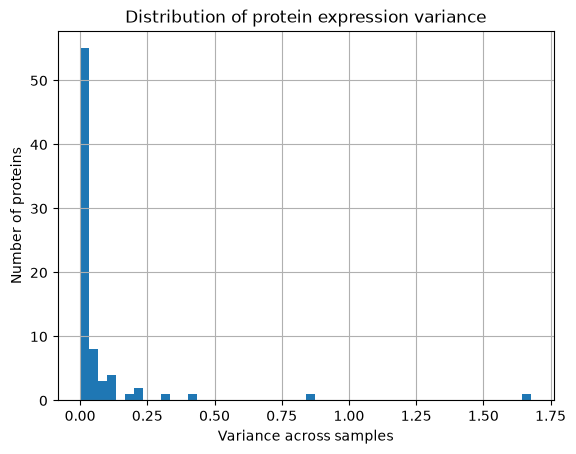

In [47]:
variances = expression_data.var()

print(data.duplicated().sum())
print(data["MouseID"].duplicated().sum())
print(data.drop(columns="MouseID").duplicated().sum())

print("Constant features:", (variances == 0).sum())
print("Median feature variance:", variances.median())

variances.hist(bins=50)
plt.xlabel("Variance across samples")
plt.ylabel("Number of proteins")
plt.title("Distribution of protein expression variance")
plt.show()

## Target, leakage, and study design

- [x] Is the target defined before modelling, with its classes or values checked for balance and validity?
    - classes seem valid and balanced, class is the target of prediction
- [x] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
    - will be done during the 3.1, only expresion data and class info will be left(ps two genes have two identical values in all of the mice, probable data duplication)
- [x] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
    - yes, and all of the available confounders r represented by the class column
- [x] Have I checked whether the target is associated with a technical or grouping variable?
    - target is assosiaed with mouse id, but split will be done with grouping by mouseid and mouse id will be removed from the modelling 
- [x] Does the planned split represent the biological generalization question?
    - yes, splitting by mouse will prevent leaking the biological data into test/train groups

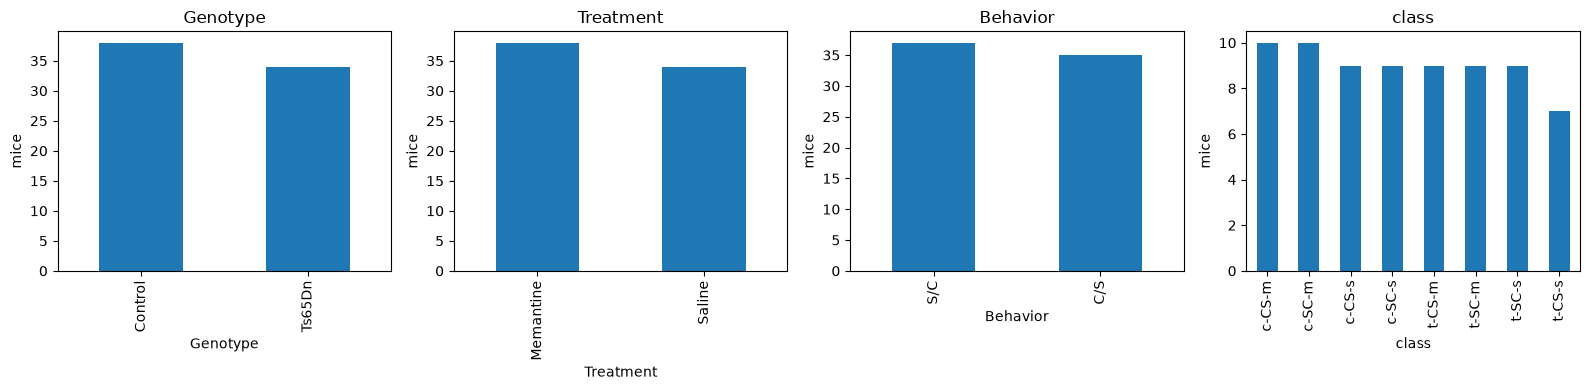

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
mouse_labels = data.drop_duplicates("mouse_id")
for ax, col in zip(axes, ["Genotype", "Treatment", "Behavior", "class"]):
    mouse_labels[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("mice")

plt.tight_layout()
plt.show()

## Reproducibility and decision record

- [x] Are random seeds, software versions, file names, and input/output shapes recorded?
    - yes(but software versions are only min-bound so they might be different)
- [x] Are all preprocessing steps placed in a reproducible pipeline?
    - will be =)
- [x] Have I recorded unresolved data-quality concerns and the decisions made about them?
    - yes(related to one mouse outlier in terms of NA and genes with NA as value)
- [x] Can another person explain what each row, column, feature, target, and grouping variable means?
    - i hope so, at least steps 3.1-3.5 are easily understandable

### 3.1 Data presentation

Describe:
- what one row represents
- what one biological mouse represents
- `MouseID` and derived `mouse_id` 
- `Genotype`, `Treatment`, `Behavior`, and `class` 
- the prediction target selected.

**Answers:**  
- what one row represents - one technical measurement
- what one biological mouse represents - the actual mouse(without dilution and replicates), 72 samples
- `MouseID` and derived `mouse_id`: MouseID is a joined id value from mouseId and dilution_level with replicate value, mouse_id is derived from MouseID
- `Genotype`, `Treatment`, `Behavior`, and `class` 
    - Genotype: control(healthy) and ts65dn(down syndrome)
    - Treatment: saline(controle) amd memantine(drug)
    - Behaviour: cs - context shock(explore first, shock second), sc - shock context(shock first, then letting explore)
    - class: combination of all above

Explain the structure of the dataset
(1080, 83)
15 lines per mouse * 72 mice -> 1080, 2 mouse id(one original and one derived biological id), 77 proteins, genotype, treatment, behaviour, class -> 83 - same as the table shape

### 3.2 Tidy-data assessment and EDA

Report:
- rows and columns: `(1080, 83)` 
- unique mice: `72` 
- measurements per mouse: `15` 
- categories and counts for Genotype, Treatment, Behavior, and class: 
    - Genotype  
        - Control    38   
        - Ts65Dn     34   
    - Treatment  
        - Memantine    38  
        - Saline       34  
    - Behavior  
        - S/C    37  
        - C/S    35  
    - class  
        - c-CS-m    10  
        - c-SC-m    10  
        - c-CS-s     9  
        - c-SC-s     9  
        - t-CS-m     9  
        - t-SC-m     9  
        - t-SC-s     9  
        - t-CS-s     7  
        
- whether the table is tidy: `yes, one row per measurement, one value - one cell. proof - 15 lines per mouse * 72 mice -> 1080, 2 mouse id(original and derived), 77 proteins, genotype, treatment, behaviour, class -> 82 - same as the table shape (1080, 82)`.


In [54]:
print(data.shape)
print(data["mouse_id"].nunique())
print(data.groupby("mouse_id").size().value_counts())

mouse_labels = data.drop_duplicates("mouse_id")
for col in ["Genotype", "Treatment", "Behavior", "class"]:
    print(col)
    print(mouse_labels[col].value_counts())



(1080, 83)
72
15    72
Name: count, dtype: int64
Genotype
Genotype
Control    38
Ts65Dn     34
Name: count, dtype: int64
Treatment
Treatment
Memantine    38
Saline       34
Name: count, dtype: int64
Behavior
Behavior
S/C    37
C/S    35
Name: count, dtype: int64
class
class
c-CS-m    10
c-SC-m    10
c-CS-s     9
c-SC-s     9
t-CS-m     9
t-SC-m     9
t-SC-s     9
t-CS-s     7
Name: count, dtype: int64


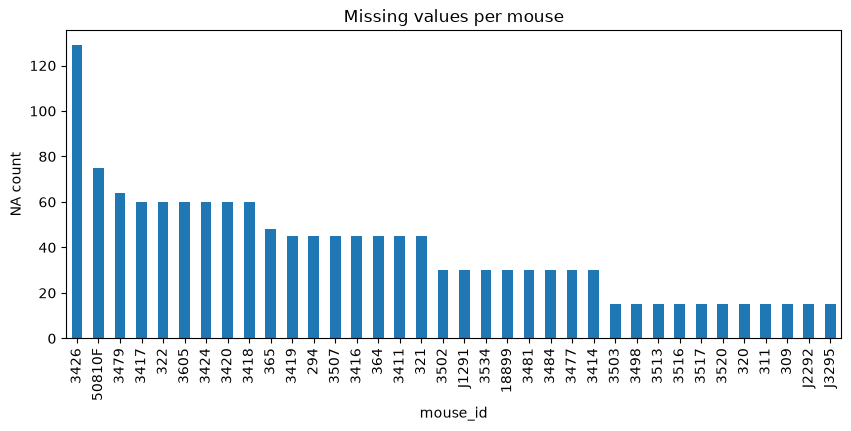

In [53]:
na_per_mouse = expression_data.isna().sum(axis=1).groupby(data["mouse_id"]).sum()
na_per_mouse[na_per_mouse > 0].sort_values(ascending=False).plot(kind="bar", figsize=(10, 4))
plt.ylabel("NA count")
plt.title("Missing values per mouse")
plt.show()


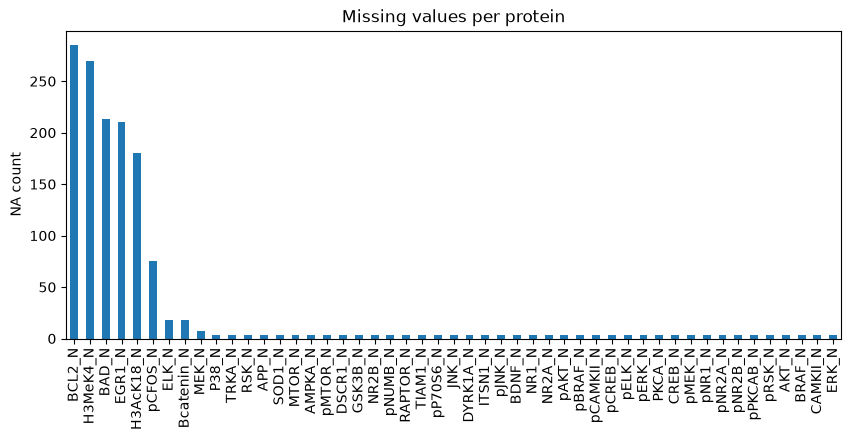

In [55]:

column_na[column_na > 0].sort_values(ascending=False).plot(kind="bar", figsize=(10, 4))
plt.ylabel("NA count")
plt.title("Missing values per protein")
plt.show()


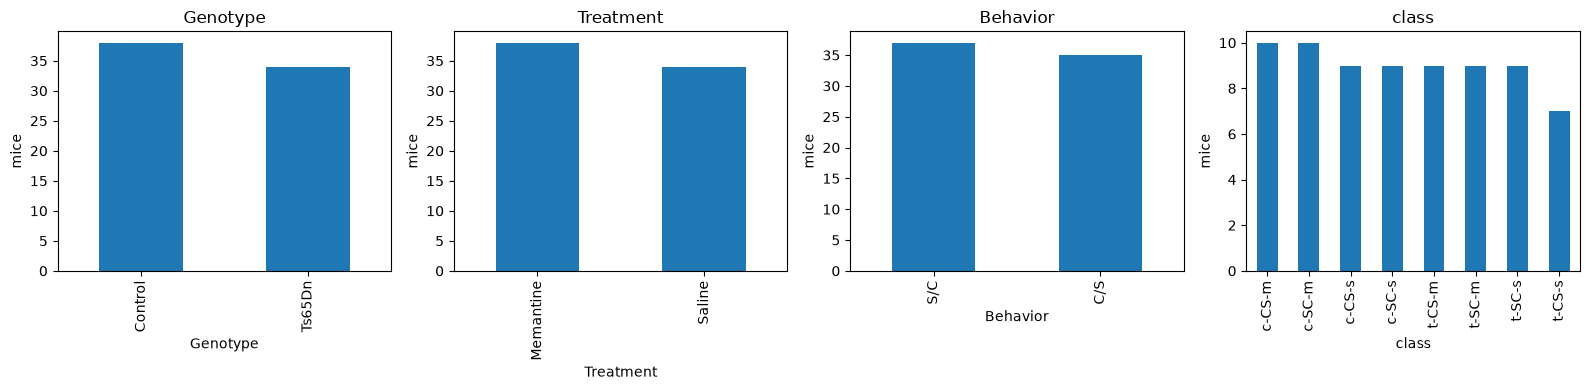

In [56]:
mouse_labels = data.drop_duplicates("mouse_id")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["Genotype", "Treatment", "Behavior", "class"]):
    mouse_labels[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("mice")

plt.tight_layout()
plt.show()

### 3.3 Diagnostics

Report checks for:
- missingness in proteins and metadata: `metadata is complete and proteins info is missing occasionally(presented at the plots above)` 
- duplicate rows or duplicate measurement identifiers: `no` 
- expected 15 measurements per mouse: `yes` 
- unusual categories or inconsistent labels: `no` 
- non-finite, negative, or implausible expression values: `no` 
- highly correlated or redundant protein variables: `there are a lot of correlated genes, but most of them could have biological grounds, but one pair has 1 as a correlation, which shows a probable data error, one of them should probably be dropped` 
- predictors that are deterministic parts of the target: `all of them, genotype, treatment, behavior, class(as a combination of those)`.

In [58]:
corr = expression_data.corr().abs()
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(corr_pairs.sort_values(ascending=False).head(20))

print((expression_data["ARC_N"] == expression_data["pS6_N"]).all())

ARC_N     pS6_N         1.000000
DYRK1A_N  BRAF_N        0.959578
          ITSN1_N       0.959512
NR1_N     pNR1_N        0.947872
DYRK1A_N  pERK_N        0.945719
pERK_N    BRAF_N        0.926984
ITSN1_N   BRAF_N        0.917608
NR1_N     Bcatenin_N    0.914610
pNR1_N    pNR2B_N       0.906504
ITSN1_N   pERK_N        0.906289
NR1_N     pNR2B_N       0.895077
          NR2A_N        0.873889
pAKT_N    pMEK_N        0.873101
pNR1_N    Bcatenin_N    0.872627
NR2A_N    pNR1_N        0.869717
          Bcatenin_N    0.866680
          pNR2B_N       0.859868
AMPKA_N   TIAM1_N       0.857801
NR1_N     TRKA_N        0.856851
ELK_N     ERK_N         0.856061
dtype: float64
True


### 3.4 Preparation and feature roles

Selected supervised-learning question: class prediction

Missing-value decision: remove mouse 3426, for missing protein values use imputer

### 3.5 Split strategy
- Independent biological unit: `mouse_id`
- Grouping variable: `mouse_id`
- Split method: `GroupShuffleSplit`

In [60]:
expression_data

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
0,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.188852,0.122652,NaN,0.106305,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652
1,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.200404,0.116682,NaN,0.106592,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610
2,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.193685,0.118508,NaN,0.108303,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427
3,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.192112,0.132781,NaN,0.103184,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563
4,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.205604,0.129954,NaN,0.104784,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,1.057971,...,0.275547,0.190483,NaN,0.115806,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823
1076,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,1.081150,...,0.283207,0.190463,NaN,0.113614,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478
1077,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,0.884342,...,0.290843,0.216682,NaN,0.118948,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825
1078,0.221242,0.412894,0.243974,1.876347,2.384088,0.208897,0.173623,2.086028,0.192044,0.922595,...,0.306701,0.222263,NaN,0.125295,0.196296,0.397676,0.335936,0.251317,0.365353,1.404031


In [59]:
clean_data = data[data["mouse_id"] != "3426"].copy()
clean_expression = expression_data.loc[clean_data.index].drop(columns="ARC_N")

target = clean_data["class"]
groups = clean_data["mouse_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(clean_expression, target, groups))

X_train = clean_expression.iloc[train_idx]
X_test = clean_expression.iloc[test_idx]

imputer = SimpleImputer(strategy="mean")
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

### 3.6 Confounding and distribution structure

Investigate associations between the target and:
- treatment 
- behavior 
- genotype 
- composite class 
- number of measurements per mouse.

Target is class itself and it relates directly to the treatment/behaviour/genotype. Number of measurement is not tied to the target as its constant(15 per mouse)